In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

# Synthetic target: sum of two Gaussians at input plane, then fit
import jax
import jax.numpy as jnp
from temgym_core.components import Detector, Lens, LensWithRotation
from temgym_core.gaussian import GaussianRay, evaluate_gaussian_input_image, make_gaussian_image
from temgym_core.plotting import plot_model, PlotParams, plot_ray_bundle, _stack_ray_positions
import numpy as np
from temgym_core.ray import Ray
jax.config.update("jax_enable_x64", True)

In [2]:
ray = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=0.0, pathlength=0.0)
lens = Lens(focal_length=-100e-3, z=0.0)
ABCD_matrix = jax.jacobian(lens(ray))

TypeError: Expected a callable value, got Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=0.0, pathlength=0.0, _one=1.0)

In [55]:
def smiley(size):
    '''
    Smiley face test object from https://doi.org/10.1093/micmic/ozad021
    '''
    obj = np.ones((size, size), dtype=np.complex64)
    y, x = np.ogrid[-size//2:size//2, -size//2:size//2]

    outline = (((y*1.2)**2 + x**2) > (110/256*size)**2) & \
              (((y*1.2)**2 + x**2) < (120/256*size)**2)
    obj[outline] = 0.0

    left_eye = ((y + 40/256*size)**2 + (x + 40/256*size)**2) < (20/256*size)**2
    obj[left_eye] = 0
    right_eye = (np.abs(y + 40/256*size) < 15/256*size) & \
                (np.abs(x - 40/256*size) < 30/256*size)
    obj[right_eye] = 0

    nose = (y + 20/256*size + x > 0) & (x < 0) & (y < 10/256*size)

    obj[nose] = (0.05j * x + 0.05j * y)[nose]

    mouth = (((y*1)**2 + x**2) > (50/256*size)**2) & \
            (((y*1)**2 + x**2) < (70/256*size)**2) & \
            (y > 20/256*size)

    obj[mouth] = 0

    tongue = (((y - 50/256*size)**2 + (x - 50/256*size)**2) < (20/256*size)**2) & \
             ((y**2 + x**2) > (70/256*size)**2)
    obj[tongue] = 0

    # This wave modulation introduces a strong signature in the diffraction pattern
    # that allows to confirm the correct scale and orientation.
    signature_wave = np.exp(1j*(3 * y + 7 * x) * 2*np.pi/size)

    obj += 0.3*signature_wave - 0.3

    return obj


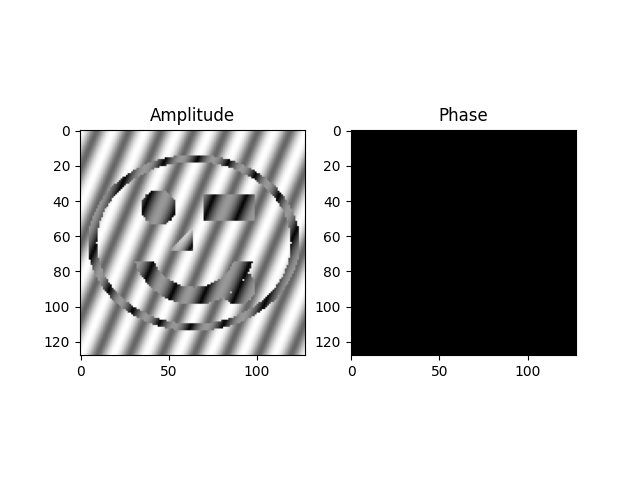

In [56]:
num_px = 128
im = np.abs(smiley(num_px))

fig, ax = plt.subplots(1, 2)
ax[0].imshow(jnp.abs(im), cmap='gray')
ax[0].set_title('Amplitude')
ax[1].imshow(jnp.angle(im), cmap='gray')
ax[1].set_title('Phase')
plt.show()

In [57]:
wavelength = 2e-12
k = 2 * jnp.pi / wavelength

input_pixel_size = 1e-9
grid = Detector(z=0.0, pixel_size=(input_pixel_size, input_pixel_size), shape=(num_px, num_px))
r1=grid.coords
xs = r1[:, 0]
ys = r1[:, 1]
n_rays = xs.shape[0]
amplitudes = jnp.abs(im).ravel()
phases = jnp.angle(im).ravel()
pathlengths = phases / k

rays = GaussianRay(
    x=xs,
    y=ys,
    dx=jnp.zeros_like(xs),
    dy=jnp.zeros_like(xs),
    z=jnp.zeros_like(xs),
    amplitude=amplitudes,
    pathlength=pathlengths,
    waist_xy = jnp.full((n_rays, 2), (0.5 * input_pixel_size)),
    radii_of_curv=jnp.full((n_rays, 2), (jnp.inf)),
    wavelength=jnp.full((n_rays,), wavelength),
    theta=jnp.zeros(n_rays),
    _one=jnp.ones(n_rays),
)

field = evaluate_gaussian_input_image(rays, grid)

field = field.reshape((num_px, num_px))

amp_diff = jnp.abs(field) - jnp.abs(im)
phase_diff = jnp.angle(field) - jnp.angle(im)

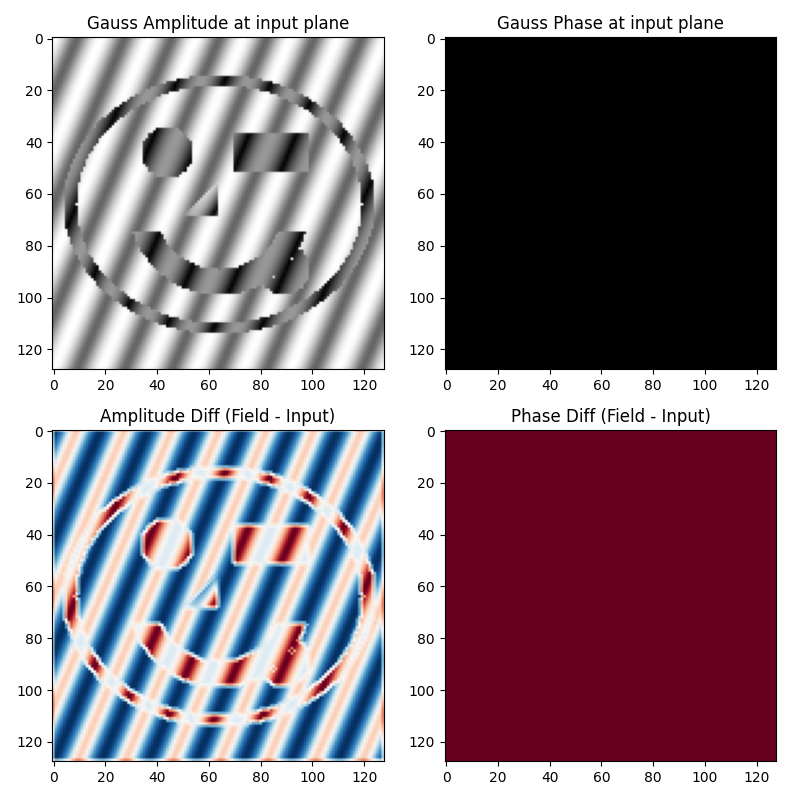

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

# Amplitude at input plane
ax[0, 0].imshow(jnp.abs(field), cmap='gray')
ax[0, 0].set_title('Gauss Amplitude at input plane')

# Phase at input plane
ax[0, 1].imshow(jnp.angle(field), cmap='gray')
ax[0, 1].set_title('Gauss Phase at input plane')

# Amplitude difference
ax[1, 0].imshow(amp_diff, cmap='RdBu')
ax[1, 0].set_title('Amplitude Diff (Field - Input)')

# Phase difference
ax[1, 1].imshow(phase_diff, cmap='RdBu')
ax[1, 1].set_title('Phase Diff (Field - Input)')

plt.tight_layout()
plt.show()


In [59]:
M1 = -100
F1 = 5.0e-3
M2 = -200
F2 = 1e-2

defocus = 1e-10
L1_z1 = F1 * (1/M1 - 1)
L1_z2 = F1 * (1 - M1)
L2_z1 = F2 * (1/M2 - 1)
L2_z2 = F2 * (1 - M2)

Lens1 = Lens(focal_length=F1 + defocus, z=abs(L1_z1))
Lens2 = Lens(focal_length=F2, z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1))
detector = Detector(z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1) + abs(L2_z2), pixel_size=(20e-6, 20e-6), shape=(128, 128))
model_1 = [
    Lens1,
    Lens2,
    detector,
]

M1 = -100
F1 = 2.5e-1
M2 = -200
F2 = 1e-1

defocus = 1e-10
L1_z1 = F1 * (1/M1 - 1)
L1_z2 = F1 * (1 - M1)
L2_z1 = F2 * (1/M2 - 1)
L2_z2 = F2 * (1 - M2)

Lens1 = Lens(focal_length=F1 + defocus, z=abs(L1_z1))
Lens2 = Lens(focal_length=F2, z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1))
detector = Detector(z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1) + abs(L2_z2), pixel_size=(20e-6, 20e-6), shape=(128, 128))
model_2 = [
    Lens1,
    Lens2,
    detector,
]

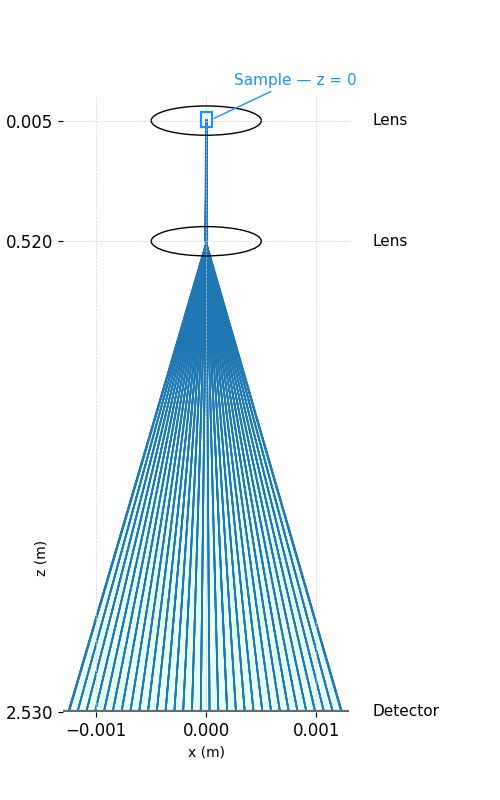

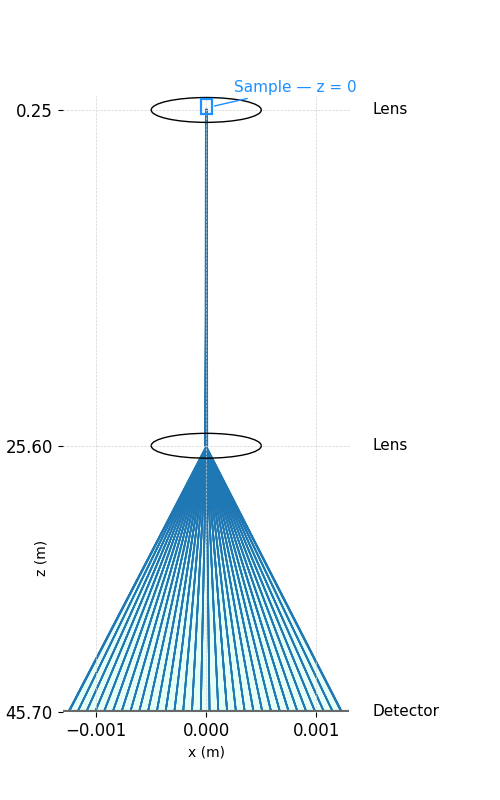

In [60]:
# --- Save ray-plot frame (diagram) ---
from matplotlib.patches import Rectangle


plot_params = PlotParams(figsize=(5, 8), extent_scale=0.01, lens_height=0.2,
                            lens_radius=1.0, label_offset=0.0015,
                            component_x=0.5e-3, min_z = -0.1, sample_side=0.0001, sample_label_offset=(0.0002, -0.2))

input_rays = rays.derive(z=jnp.zeros(n_rays)+defocus)
det_image_model_one = make_gaussian_image(input_rays, model_1, batch_size=1000)

fig_rays1, ax_rays1 = plot_model(model_1, rays=input_rays[1::100], plot_params=plot_params)

plot_params = PlotParams(figsize=(5, 8), extent_scale=0.01, lens_height=3,
                            lens_radius=1.0, label_offset=0.0015,
                            component_x=0.5e-3, min_z = -0.8, sample_side=0.0001, sample_label_offset=(0.0002, -2.0))


input_rays = rays.derive(z=jnp.zeros(n_rays)+defocus)
det_image_model_two = make_gaussian_image(input_rays, model_2, batch_size=1000)
fig_rays2, ax_rays2 = plot_model(model_2, rays=input_rays[1::100], plot_params=plot_params)


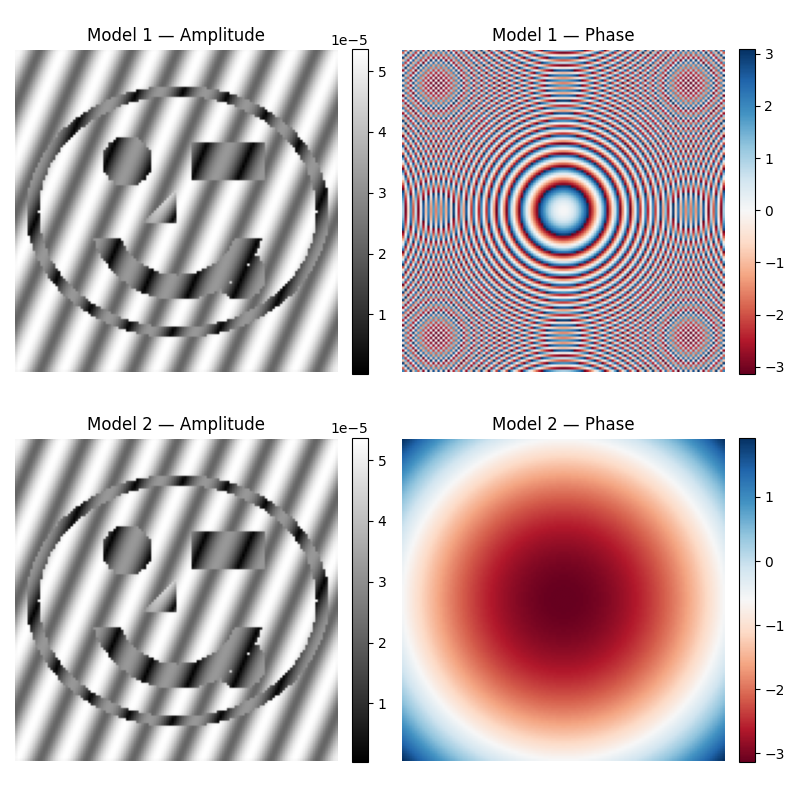

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.ravel()

im0 = ax[0].imshow(jnp.abs(det_image_model_one), cmap='gray')
ax[0].set_title('Model 1 — Amplitude')
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(jnp.angle(det_image_model_one), cmap='RdBu')
ax[1].set_title('Model 1 — Phase')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(jnp.abs(det_image_model_two), cmap='gray')
ax[2].set_title('Model 2 — Amplitude')
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(jnp.angle(det_image_model_two), cmap='RdBu')
ax[3].set_title('Model 2 — Phase')
fig.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_513929/4107816301.py:60: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images_det = [imageio.imread(f) for f in frame_files_det]
/tmp/ipykernel_513929/4107816301.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images_rays = [imageio.imread(f) for f in frame_files_rays]


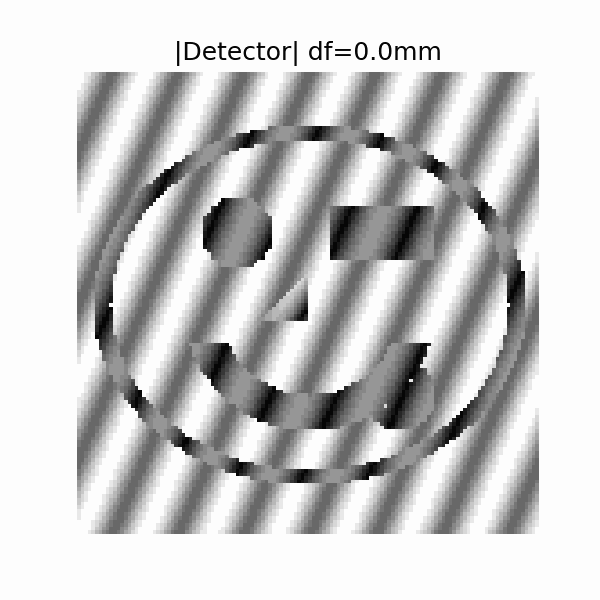

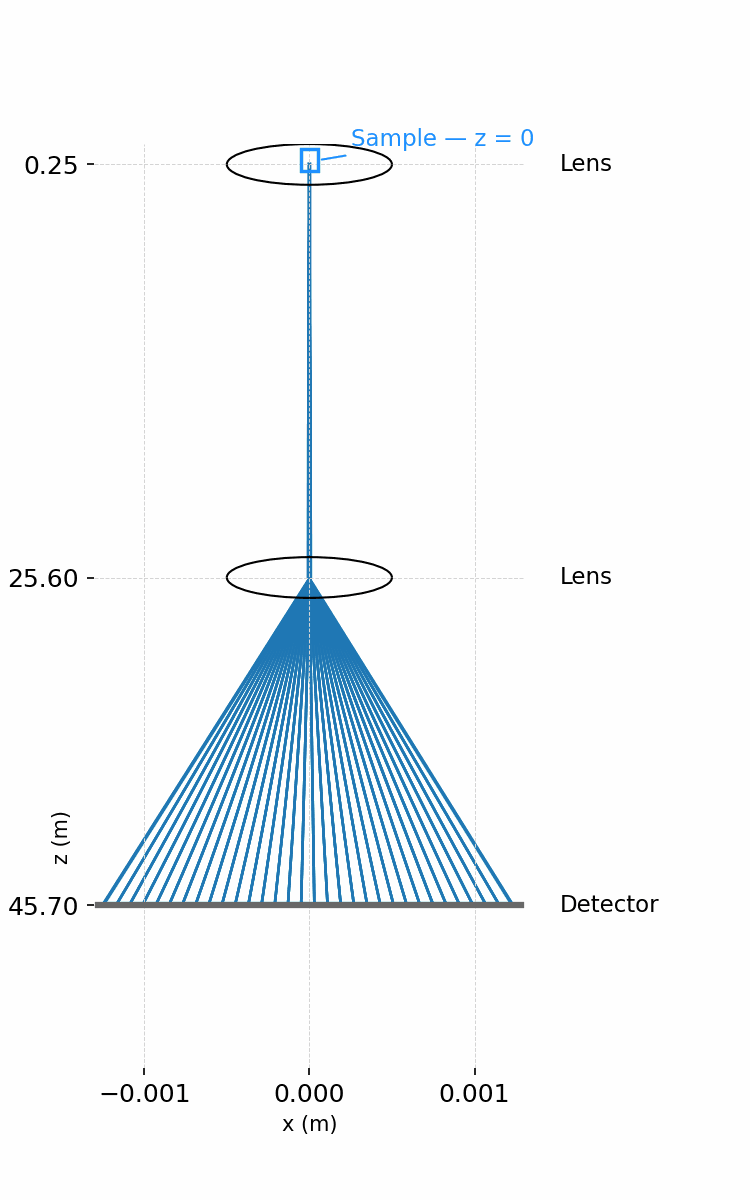

In [68]:
from matplotlib.patches import Rectangle
import imageio
from IPython.display import Image as IPyImage, display
import os

# output dirs
frames_dir_det = "frames_defocus_detector"
frames_dir_rays = "frames_defocus_rays"
os.makedirs(frames_dir_det, exist_ok=True)
os.makedirs(frames_dir_rays, exist_ok=True)

frame_files_det = []
frame_files_rays = []

# use the same dfs as before (can be changed to more frames)
dfs = np.linspace(0, 10, 10)

# Precompute fixed z-limits so the detector moves within a stable frame
z_base = abs(L1_z1) + abs(L1_z2) + abs(L2_z1)
z_det0 = z_base + abs(L2_z2)
z_max_fixed = float(z_det0 + np.max(dfs))  # top of axis (remember: axis is inverted)
z_min_fixed = -1  # keep the sample at z=0 visible below top

for i, df in enumerate(dfs):
    # build model for this defocus
    Lens1 = Lens(focal_length=F1, z=abs(L1_z1))
    Lens2 = Lens(focal_length=F2, z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1))
    detector = Detector(z=abs(L1_z1) + abs(L1_z2) + abs(L2_z1) + abs(L2_z2) + df,
                        pixel_size=(20e-6, 20e-6), shape=(128, 128))
    model = [Lens1, Lens2, detector]

    # detector image (intensity)
    det_image = make_gaussian_image(input_rays, model, batch_size=1000)

    # --- Save detector image frame ---
    fig_det, ax_det = plt.subplots(1, 1, figsize=(4, 4))
    ax_det.imshow(jnp.abs(det_image), cmap='gray')
    ax_det.set_title(f'|Detector| df={df*1e3:.1f}mm')
    ax_det.axis('off')
    fname_det = os.path.join(frames_dir_det, f'det_frame_{i:03d}.png')
    fig_det.savefig(fname_det, dpi=150)
    frame_files_det.append(fname_det)
    plt.close(fig_det)

    # --- Save ray-plot frame (diagram) ---
    plot_params = PlotParams(figsize=(5, 8), extent_scale=0.01, lens_height=4,
                             lens_radius=1.0, label_offset=0.0015,
                             min_z=z_min_fixed, max_z=z_max_fixed,
                             component_x=0.5e-3, sample_side=0.0001, sample_label_offset=(0.0002, -2.0))
    fig_rays, ax_rays = plot_model(model, rays=rays[1::100], plot_params=plot_params)


    fname_rays = os.path.join(frames_dir_rays, f'ray_frame_{i:03d}.png')
    fig_rays.savefig(fname_rays, dpi=150)
    frame_files_rays.append(fname_rays)
    plt.close(fig_rays)

# create GIFs
gif_det = "tem_simulation_defocus_detector_dL2.gif"
images_det = [imageio.imread(f) for f in frame_files_det]
imageio.mimsave(gif_det, images_det, duration=0.05)

gif_rays = "tem_simulation_defocus_rays_dL2.gif"
images_rays = [imageio.imread(f) for f in frame_files_rays]
imageio.mimsave(gif_rays, images_rays, duration=0.05)

# display inline
display(IPyImage(gif_det))
display(IPyImage(gif_rays))


In [63]:
# Precompute fixed z-limits so the detector moves within a stable frame
z_base = abs(L1_z1) + abs(L1_z2) + abs(L2_z1)
z_det0 = z_base + abs(L2_z2)
z_max_fixed = float(z_det0 + np.max(dfs))  # top of axis (remember: axis is inverted)
z_min_fixed = -0.01  # keep the sample at z=0 visible below top